In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#2. Create the XOR dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("X:")
print(X)

print("\ny:")
print(y)

X:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

y:
[[0.]
 [1.]
 [1.]
 [0.]]


In [6]:
#3. Build and train MLP using Keras
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Dense(4, activation="tanh", input_shape=(2,)),
    keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X, y,
    epochs=500,
    verbose=0
)

In [7]:
#4. Evaluate Keras model
loss, accuracy = model.evaluate(X, y, verbose=0)

print("Keras Accuracy:", accuracy)

Keras Accuracy: 0.75


In [8]:
#5. Predict XOR outputs
predictions = model.predict(X, verbose=0)

print("Keras Predictions:")

for i in range(len(X)):
    output = 1 if predictions[i][0] >= 0.5 else 0
    print(X[i], "->", output)

Keras Predictions:
[0. 0.] -> 0
[0. 1.] -> 1
[1. 0.] -> 1
[1. 1.] -> 1


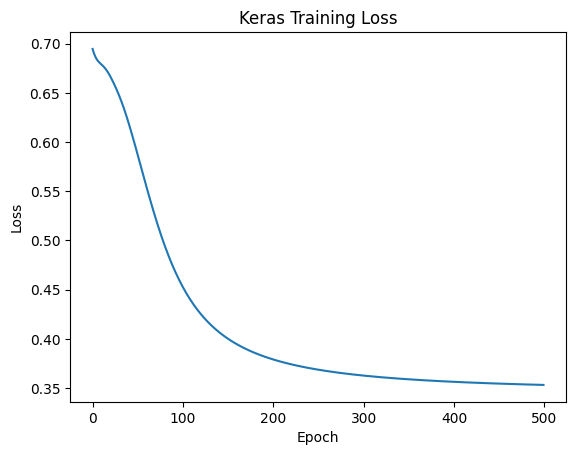

In [9]:
#6. Keras training curve
plt.plot(history.history["loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Keras Training Loss")

plt.show()

In [10]:
#7. Create PyTorch model
import torch
import torch.nn as nn
import torch.optim as optim

X_torch = torch.tensor(X)
y_torch = torch.tensor(y)


class XORModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)

    def forward(self, x):
        x = torch.tanh(self.hidden(x))
        x = torch.sigmoid(self.output(x))
        return x


model_torch = XORModel()

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model_torch.parameters(),
    lr=0.01
)

In [11]:
#8. Train PyTorch model
losses = []

for epoch in range(500):

    output = model_torch(X_torch)

    loss = criterion(output, y_torch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

In [12]:
#9. Evaluate PyTorch model
with torch.no_grad():

    predictions = model_torch(X_torch)

    predicted_classes = (
        predictions >= 0.5
    ).float()

    accuracy = (
        predicted_classes == y_torch
    ).float().mean()

print("PyTorch Accuracy:", accuracy.item())

PyTorch Accuracy: 1.0


In [13]:
#10. PyTorch predictions
with torch.no_grad():

    predictions = model_torch(X_torch)

    for i in range(len(X)):
        output = 1 if predictions[i][0] >= 0.5 else 0
        print(X[i], "->", output)

[0. 0.] -> 0
[0. 1.] -> 1
[1. 0.] -> 1
[1. 1.] -> 0


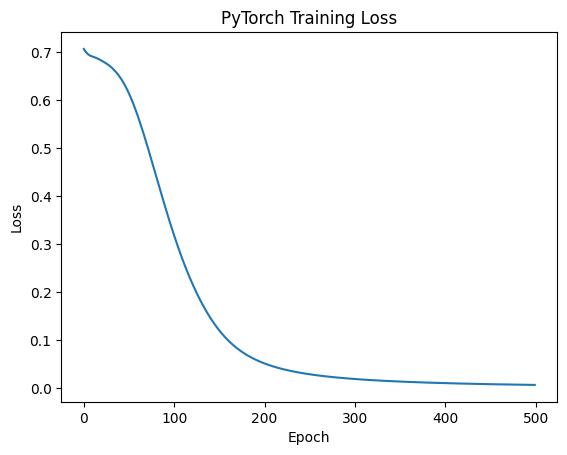

In [14]:
#11. PyTorch loss graph
plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PyTorch Training Loss")

plt.show()

In [15]:
# 12. Build TensorFlow model
import tensorflow as tf

X_tf = tf.constant(X)
y_tf = tf.constant(y)

W1 = tf.Variable(
    tf.random.normal([2, 4])
)

b1 = tf.Variable(
    tf.zeros([4])
)

W2 = tf.Variable(
    tf.random.normal([4, 1])
)

b2 = tf.Variable(
    tf.zeros([1])
)

learning_rate = 0.01

In [16]:
# 13. Forward pass
def forward(X):

    hidden = tf.tanh(
        tf.matmul(X, W1) + b1
    )

    output = tf.sigmoid(
        tf.matmul(hidden, W2) + b2
    )

    return output

In [17]:
# 14. Train TensorFlow model
losses_tf = []

for epoch in range(500):

    with tf.GradientTape() as tape:

        predictions = forward(X_tf)

        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(
                y_tf,
                predictions
            )
        )

    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )

    W1.assign_sub(
        learning_rate * gradients[0]
    )

    b1.assign_sub(
        learning_rate * gradients[1]
    )

    W2.assign_sub(
        learning_rate * gradients[2]
    )

    b2.assign_sub(
        learning_rate * gradients[3]
    )

    losses_tf.append(loss.numpy())

In [18]:
# 15. Evaluate TensorFlow model
predictions = forward(X_tf)

predicted_classes = tf.cast(
    predictions >= 0.5,
    tf.float32
)

accuracy = tf.reduce_mean(
    tf.cast(
        predicted_classes == y_tf,
        tf.float32
    )
)

print("TensorFlow Accuracy:", accuracy.numpy())

TensorFlow Accuracy: 0.75


In [19]:
# 16. TensorFlow predictions
predictions = forward(X_tf)

for i in range(len(X)):

    output = 1 if predictions[i][0] >= 0.5 else 0

    print(X[i], "->", output)

[0. 0.] -> 0
[0. 1.] -> 1
[1. 0.] -> 1
[1. 1.] -> 1


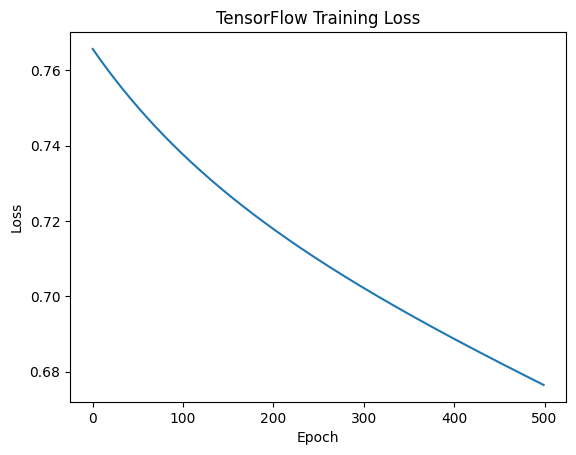

In [20]:
# 17. TensorFlow training curve
plt.plot(losses_tf)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TensorFlow Training Loss")

plt.show()

In [22]:
# 18. Compare all three libraries
keras_accuracy = 0.0
# Keras accuracy value from cell 4
keras_accuracy = model.evaluate(X, y, verbose=0)[1]

# PyTorch accuracy value from cell 9
pytorch_accuracy = (
    ((model_torch(X_torch) >= 0.5).float() == y_torch).float().mean().item()
)

# TensorFlow accuracy value from cell 15
tf_accuracy = float(accuracy.numpy())

print("MODEL PERFORMANCE")
print("------------------")
print("Keras Accuracy:", keras_accuracy)
print("PyTorch Accuracy:", pytorch_accuracy)
print("TensorFlow Accuracy:", tf_accuracy)

MODEL PERFORMANCE
------------------
Keras Accuracy: 0.75
PyTorch Accuracy: 1.0
TensorFlow Accuracy: 0.75
